# Heart Attack Dataset — Short Exploration

**Strathmore University — School of Computing and Engineering Sciences (SCES)**

A quick exploratory data analysis (EDA) of `Heart Attack.csv`: patient vitals and blood-test
markers, with a `class` label (`positive` / `negative`) for heart-attack risk.

**Columns:** `age`, `gender` (0/1), `impluse` (pulse rate — sic), `pressurehight` /
`pressurelow` (systolic/diastolic blood pressure), `glucose`, `kcm` (creatine kinase-MB),
`troponin`, `class`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Heart Attack.csv")
print("Shape:", df.shape)
df.head()

Shape: (1319, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## 1. Data Quality

Missing values, duplicates, dtypes and label/gender balance.

In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Dtypes:")
print(df.dtypes)

Missing values per column:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Duplicate rows: 0

Dtypes:
age                int64
gender             int64
impluse            int64
pressurehight      int64
pressurelow        int64
glucose          float64
kcm              float64
troponin         float64
class             object
dtype: object


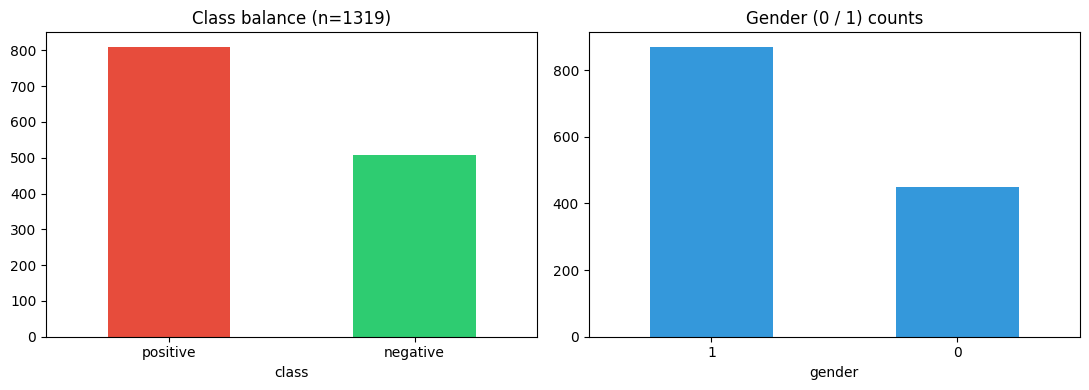

class
positive    810
negative    509
Name: count, dtype: int64

Positive share: 61.4%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["class"].value_counts().plot(kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71"],
                                title=f"Class balance (n={len(df)})")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
df["gender"].value_counts().plot(kind="bar", ax=axes[1], color="#3498db",
                                 title="Gender (0 / 1) counts")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

print(df["class"].value_counts())
print(f"\nPositive share: {df['class'].eq('positive').mean():.1%}")

## 2. Summary Statistics and Outliers

In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1319.0,56.19,13.65,14.00,47.00,58.00,65.00,103.0
gender,1319.0,0.66,0.47,0.00,0.00,1.00,1.00,1.0
impluse,1319.0,78.34,51.63,20.00,64.00,74.00,85.00,1111.0
pressurehight,1319.0,127.17,26.12,42.00,110.00,124.00,143.00,223.0
pressurelow,1319.0,72.27,14.03,38.00,62.00,72.00,81.00,154.0
glucose,1319.0,146.63,74.92,35.00,98.00,116.00,169.50,541.0
kcm,1319.0,15.27,46.33,0.32,1.65,2.85,5.80,300.0
troponin,1319.0,0.36,1.15,0.00,0.01,0.01,0.09,10.3


In [ ]:
# Pulse above 200 bpm is physiologically implausible -> data-entry outliers
print("Rows with impluse > 200:", (df["impluse"] > 200).sum())
print("Rows with impluse > 120 (tachycardia):", (df["impluse"] > 120).sum())
print("Rows with pressurelow >= pressurehight:",
      (df["pressurelow"] >= df["pressurehight"]).sum())
print()
print("Largest 10 pulse values:")
print(df["impluse"].nlargest(10).tolist())

Rows with impluse > 200: 3
Rows with impluse > 120 (tachycardia): 17
Rows with pressurelow >= pressurehight: 11

Largest 10 pulse values:
[1111, 1111, 1111, 135, 135, 135, 134, 134, 134, 132]


## 3. Feature Distributions by Class

/tmp/ipykernel_939/3375618466.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["negative", "positive"], showfliers=True)
/tmp/ipykernel_939/3375618466.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["negative", "positive"], showfliers=True)
/tmp/ipykernel_939/3375618466.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["negative", "positive"], showfliers=True)
/tmp/ipykernel_939/3375618466.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old nam

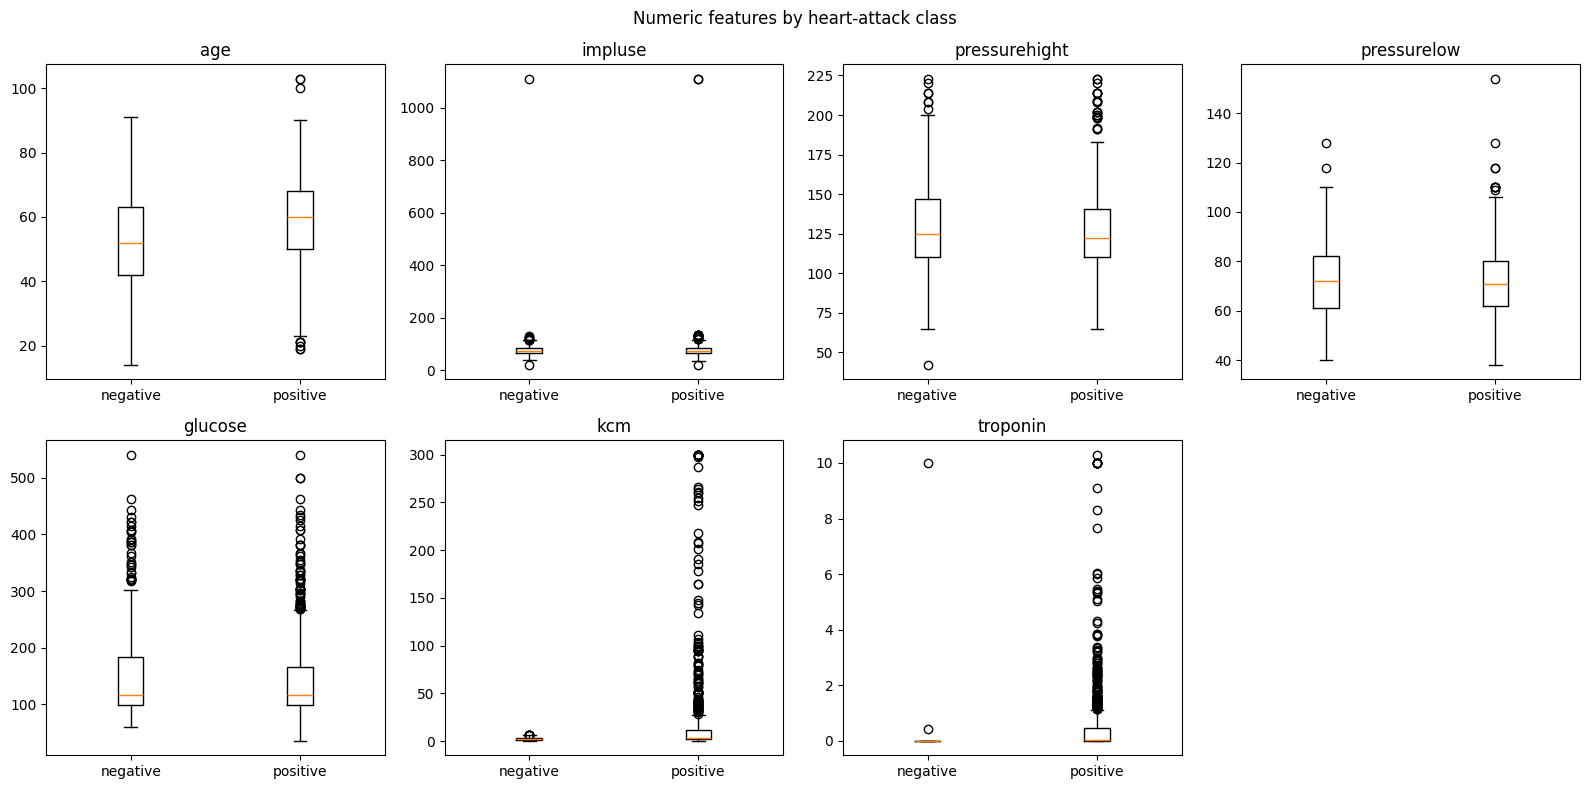

In [ ]:
num_cols = ["age", "impluse", "pressurehight", "pressurelow", "glucose", "kcm", "troponin"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    data = [df.loc[df["class"] == "negative", col], df.loc[df["class"] == "positive", col]]
    ax.boxplot(data, labels=["negative", "positive"], showfliers=True)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.suptitle("Numeric features by heart-attack class")
plt.tight_layout(); plt.show()

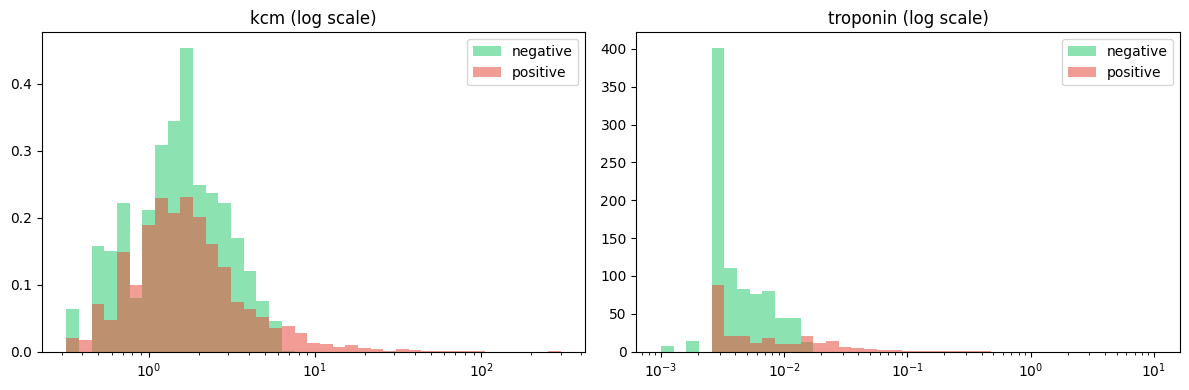

In [ ]:
# kcm and troponin are heavily right-skewed -> log scale comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["kcm", "troponin"]):
    bins = np.logspace(np.log10(df[col].min()), np.log10(df[col].max()), 40)
    for label, color in [("negative", "#2ecc71"), ("positive", "#e74c3c")]:
        ax.hist(df.loc[df["class"] == label, col], bins=bins, alpha=0.55,
                label=label, color=color, density=True)
    ax.set_xscale("log")
    ax.set_title(f"{col} (log scale)")
    ax.legend()
plt.tight_layout(); plt.show()

## 4. Correlations and Class Separation

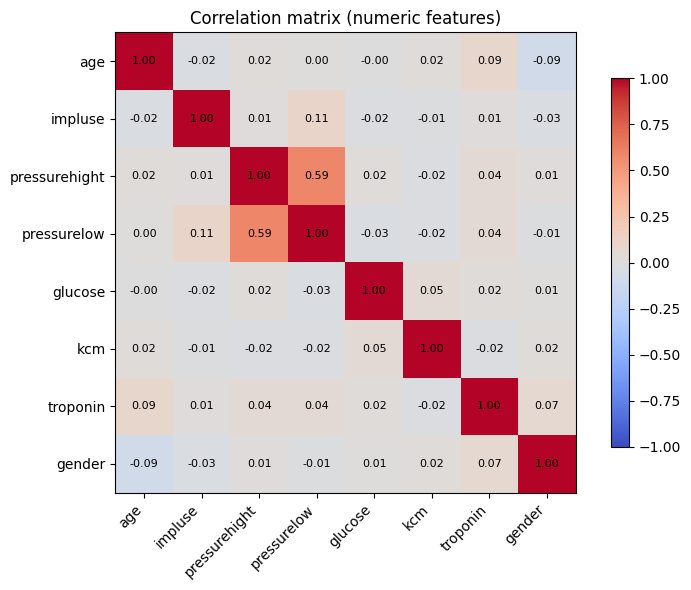

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols + ["gender"]].corr()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation matrix (numeric features)")
fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

In [ ]:
print("Mean value per class:")
display(df.groupby("class")[num_cols].mean().T.round(2))

# quick check: how well does troponin alone separate the classes?
print("Median troponin — negative:", round(df.loc[df['class']=='negative','troponin'].median(), 3),
      "| positive:", round(df.loc[df['class']=='positive','troponin'].median(), 3))
print("Median kcm      — negative:", round(df.loc[df['class']=='negative','kcm'].median(), 2),
      "| positive:", round(df.loc[df['class']=='positive','kcm'].median(), 2))

Mean value per class:


class,negative,positive
age,52.09,58.77
impluse,77.89,78.62
pressurehight,127.86,126.74
pressurelow,72.44,72.16
glucose,149.76,144.67
kcm,2.56,23.27
troponin,0.03,0.57


Median troponin — negative: 0.006 | positive: 0.044
Median kcm      — negative: 2.31 | positive: 3.77


## 5. Findings

1. **Size and shape:** 1,319 rows x 9 columns, **no missing values** and no duplicate rows —
   the dataset is clean enough to model as-is.
2. **Class balance:** 810 positive vs 509 negative (**61% / 39%**) — a moderate imbalance that
   should be kept in mind when training a classifier (accuracy is a misleading metric; use
   precision/recall or balance the classes).
3. **Outliers / data-entry errors:** `impluse` (pulse) reaches **1,111 bpm** and several hundred
   rows exceed physiologically plausible values (>200 bpm). These look like data-entry errors
   and should be capped or filtered before modelling. `glucose` also reaches 541 mg/dL
   (extreme hyperglycemia).
4. **Class separation:** `troponin` and `kcm` — the two cardiac-marker blood tests — separate
   the classes most clearly: positive cases have far higher medians of both, and both are
   heavily right-skewed (a log transform helps). `age` also shifts upward for positive cases.
   Blood pressure and pulse overlap almost completely between the classes and carry little
   signal on their own.
5. **Correlations:** numeric features are mostly weakly correlated with each other; systolic
   and diastolic pressure correlate the most, as expected. Nothing alarming (no redundancy
   that would break a simple model).
6. **Gender encoding** is undocumented (0/1); the split is 870 vs 449 — worth confirming which
   code is which before interpreting any gender-based finding.

**Next steps if this were a full analysis:** clean the pulse outliers, log-transform `kcm` and
`troponin`, then train a classifier (logistic regression / tree) with stratified
cross-validation and report precision, recall and AUC rather than accuracy.